Данная работа была выполнена в колабе, так как тут есть Tesla T4 и работа с нейросетями заметно быстрее

# Тема курсового проекта
Генерация конспекта по видео лекции: На вход подается видео запись лекции, задача: распознать содержание (SpeechToText) и сгенерировать краткую выжимку с основными тезисами - конспект.

## Рассматриваемые модели

T5-small ~240 MB - лёгкая базовая модель

BART-base ~550 MB - предобучена на суммаризации

Flan-T5-base ~990 MB - улучшенная версия T5

## обучение
Все три модели обучаются одинаково через Seq2SeqTrainer из библиотеки
HuggingFace Transformers на одном и том же датасете из Лабы 3.

## Метрика сравнения
Модели сравниваются по ROUGE (ROUGE-1, ROUGE-2, ROUGE-L) на тестовой
выборке test.csv, которая не участвовала в обучении.

# Установка библиотек

In [ ]:
%pip install transformers datasets rouge-score sentencepiece accelerate pandas torch

# Загрузка датасета

In [ ]:
import pandas as pd

train = pd.read_parquet('dataset/train.parquet')
val = pd.read_parquet('dataset/val.parquet')
test = pd.read_parquet('dataset/test.parquet')

train = train[['transcript', 'summary']]
val = val[['transcript', 'summary']]
test = test[['transcript', 'summary']]

print(f"Train: {len(train)}")
print(f"Val:   {len(val)}")
print(f"Test:  {len(test)}")

Train: 2166
Val:   310
Test:  620


In [ ]:
eval_strategy_key = 'eval_strategy'

# Модель 1 - T5

In [ ]:
from transformers import (
    AutoTokenizer, AutoModelForSeq2SeqLM,
    Seq2SeqTrainer, Seq2SeqTrainingArguments,
    DataCollatorForSeq2Seq
)
from datasets import Dataset
import torch

MODEL_NAME = "google-t5/t5-small"

tokenizer_t5 = AutoTokenizer.from_pretrained(MODEL_NAME)
model_t5 = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)

print(f"Модель загружена: {MODEL_NAME}")
print(f"Параметров: {model_t5.num_parameters():,}")

MAX_INPUT_LEN = 512
MAX_TARGET_LEN = 128
PREFIX = "summarize: "

def tokenize(batch):
    inputs = [PREFIX + text for text in batch['transcript']]
    model_inputs = tokenizer_t5(
        inputs,
        max_length=MAX_INPUT_LEN,
        truncation=True,
        padding=False
    )
    labels = tokenizer_t5(
        text_target=batch['summary'],
        max_length=MAX_TARGET_LEN,
        truncation=True,
        padding=False
    )
    model_inputs['labels'] = labels['input_ids']
    return model_inputs

train_ds_t5 = Dataset.from_pandas(train).map(tokenize, batched=True)
val_ds_t5 = Dataset.from_pandas(val).map(tokenize, batched=True)

training_args_t5 = Seq2SeqTrainingArguments(
    output_dir='./results/t5-small',
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    warmup_steps=100,
    weight_decay=0.01,
    logging_dir='./logs/t5-small',
    logging_steps=50,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    predict_with_generate=True,
    fp16=torch.cuda.is_available(),
    report_to='none'
)

data_collator_t5 = DataCollatorForSeq2Seq(tokenizer_t5, model=model_t5)

trainer_t5 = Seq2SeqTrainer(
    model=model_t5,
    args=training_args_t5,
    train_dataset=train_ds_t5,
    eval_dataset=val_ds_t5,
    processing_class=tokenizer_t5,
    data_collator=data_collator_t5,
)

print("Начинаем обучение T5-small...")
trainer_t5.train()
print("✅ Обучение T5-small завершено")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight', 'lm_head.weight'].


✅ Обучение T5-small завершено


In [ ]:
import numpy as np

def generate_summary(model, tokenizer, text, prefix="summarize: ", max_input=512, max_output=128):
    input_text = prefix + text
    inputs = tokenizer(
        input_text,
        max_length=max_input,
        truncation=True,
        return_tensors='pt'
    ).to(model.device)

    outputs = model.generate(
        **inputs,
        max_new_tokens=max_output,
        num_beams=4,
        early_stopping=True
    )
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

model_t5.eval()
model_t5.to('cuda' if torch.cuda.is_available() else 'cpu')

# Берём только 100 записей для оценки
test_sample = test.sample(100, random_state=42).reset_index(drop=True)

print("Генерируем предсказания T5-small...")

predictions_t5 = []
references_t5 = []

for i, row in test_sample.iterrows():
    pred = generate_summary(model_t5, tokenizer_t5, row['transcript'])
    predictions_t5.append(pred)
    references_t5.append(row['summary'])

    if i % 20 == 0:
        print(f"  Обработано: {i}/100")

print("✅ Инференс завершён")

Генерируем предсказания T5-small...
  Обработано: 0/100
  Обработано: 20/100
  Обработано: 40/100
  Обработано: 60/100
  Обработано: 80/100
✅ Инференс завершён


In [ ]:
from rouge_score import rouge_scorer

scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)

rouge1_scores, rouge2_scores, rougeL_scores = [], [], []

for pred, ref in zip(predictions_t5, references_t5):
    scores = scorer.score(ref, pred)
    rouge1_scores.append(scores['rouge1'].fmeasure)
    rouge2_scores.append(scores['rouge2'].fmeasure)
    rougeL_scores.append(scores['rougeL'].fmeasure)

results_t5 = {
    'model': 'T5-small',
    'ROUGE-1': round(np.mean(rouge1_scores), 4),
    'ROUGE-2': round(np.mean(rouge2_scores), 4),
    'ROUGE-L': round(np.mean(rougeL_scores), 4),
}

print("\n=== Результаты T5-small ===")
print(f"ROUGE-1: {results_t5['ROUGE-1']}")
print(f"ROUGE-2: {results_t5['ROUGE-2']}")
print(f"ROUGE-L: {results_t5['ROUGE-L']}")


=== Результаты T5-small ===
ROUGE-1: 0.3336
ROUGE-2: 0.133
ROUGE-L: 0.2331


# Модель 2 — BART-base

In [ ]:
BART_MODEL_NAME = "facebook/bart-base"

tokenizer_bart = AutoTokenizer.from_pretrained(BART_MODEL_NAME)
model_bart = AutoModelForSeq2SeqLM.from_pretrained(BART_MODEL_NAME)

print(f"Модель загружена: {BART_MODEL_NAME}")
print(f"Параметров: {model_bart.num_parameters():,}")

def tokenize_bart(batch):
    model_inputs = tokenizer_bart(
        batch['transcript'],  # BART не требует префикса
        max_length=512,
        truncation=True,
        padding=False
    )
    labels = tokenizer_bart(
        text_target=batch['summary'],
        max_length=128,
        truncation=True,
        padding=False
    )
    model_inputs['labels'] = labels['input_ids']
    return model_inputs

train_ds_bart = Dataset.from_pandas(train).map(tokenize_bart, batched=True)
val_ds_bart = Dataset.from_pandas(val).map(tokenize_bart, batched=True)

print(f"\nТокенизация завершена")
print(f"Train: {len(train_ds_bart)} записей")
print(f"Val:   {len(val_ds_bart)} записей")

training_args_bart = Seq2SeqTrainingArguments(
    output_dir='./results/bart-base',
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    warmup_steps=100,
    weight_decay=0.01,
    logging_steps=50,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    predict_with_generate=True,
    fp16=torch.cuda.is_available(),
    report_to='none'
)

data_collator_bart = DataCollatorForSeq2Seq(tokenizer_bart, model=model_bart)

trainer_bart = Seq2SeqTrainer(
    model=model_bart,
    args=training_args_bart,
    train_dataset=train_ds_bart,
    eval_dataset=val_ds_bart,
    processing_class=tokenizer_bart,
    data_collator=data_collator_bart,
)

print("Начинаем обучение BART-base...")
trainer_bart.train()
print("✅ Обучение BART-base завершено")

Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

Модель загружена: facebook/bart-base
Параметров: 139,420,416


Map:   0%|          | 0/2166 [00:00<?, ? examples/s]

Map:   0%|          | 0/310 [00:00<?, ? examples/s]


Токенизация завершена
Train: 2166 записей
Val:   310 записей
Начинаем обучение BART-base...


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['model.encoder.embed_tokens.weight', 'model.decoder.embed_tokens.weight', 'lm_head.weight'].


✅ Обучение BART-base завершено


In [ ]:

# Инференс BART-base

model_bart.eval()
model_bart.to('cuda' if torch.cuda.is_available() else 'cpu')

print("Генерируем предсказания BART-base...")

predictions_bart = []
references_bart = []

for i, row in test_sample.iterrows():
    pred = generate_summary(model_bart, tokenizer_bart, row['transcript'], prefix="")
    predictions_bart.append(pred)
    references_bart.append(row['summary'])

    if i % 20 == 0:
        print(f"  Обработано: {i}/100")

print("✅ Инференс завершён")


# Считаем ROUGE

rouge1_scores, rouge2_scores, rougeL_scores = [], [], []

for pred, ref in zip(predictions_bart, references_bart):
    scores = scorer.score(ref, pred)
    rouge1_scores.append(scores['rouge1'].fmeasure)
    rouge2_scores.append(scores['rouge2'].fmeasure)
    rougeL_scores.append(scores['rougeL'].fmeasure)

results_bart = {
    'model': 'BART-base',
    'ROUGE-1': round(np.mean(rouge1_scores), 4),
    'ROUGE-2': round(np.mean(rouge2_scores), 4),
    'ROUGE-L': round(np.mean(rougeL_scores), 4),
}

print("\n=== Результаты BART-base ===")
print(f"ROUGE-1: {results_bart['ROUGE-1']}")
print(f"ROUGE-2: {results_bart['ROUGE-2']}")
print(f"ROUGE-L: {results_bart['ROUGE-L']}")

Генерируем предсказания BART-base...
  Обработано: 0/100
  Обработано: 20/100
  Обработано: 40/100
  Обработано: 60/100
  Обработано: 80/100
✅ Инференс завершён

=== Результаты BART-base ===
ROUGE-1: 0.3605
ROUGE-2: 0.1492
ROUGE-L: 0.2611


# Модель 3 — Flan-T5-base

In [ ]:
FLAN_MODEL_NAME = "google/flan-t5-base"

tokenizer_flan = AutoTokenizer.from_pretrained(FLAN_MODEL_NAME)
model_flan = AutoModelForSeq2SeqLM.from_pretrained(FLAN_MODEL_NAME)

print(f"Модель загружена: {FLAN_MODEL_NAME}")
print(f"Параметров: {model_flan.num_parameters():,}")

def tokenize_flan(batch):
    inputs = ["summarize: " + text for text in batch['transcript']]
    model_inputs = tokenizer_flan(
        inputs,
        max_length=512,
        truncation=True,
        padding=False
    )
    labels = tokenizer_flan(
        text_target=batch['summary'],
        max_length=128,
        truncation=True,
        padding=False
    )
    model_inputs['labels'] = labels['input_ids']
    return model_inputs

train_ds_flan = Dataset.from_pandas(train).map(tokenize_flan, batched=True)
val_ds_flan = Dataset.from_pandas(val).map(tokenize_flan, batched=True)

print(f"\nТокенизация завершена")
print(f"Train: {len(train_ds_flan)} записей")
print(f"Val:   {len(val_ds_flan)} записей")

training_args_flan = Seq2SeqTrainingArguments(
    output_dir='./results/flan-t5-base',
    num_train_epochs=3,
    per_device_train_batch_size=4,  # меньше batch из-за размера модели
    per_device_eval_batch_size=4,
    warmup_steps=100,
    weight_decay=0.01,
    logging_steps=50,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    predict_with_generate=True,
    fp16=torch.cuda.is_available(),
    report_to='none'
)

data_collator_flan = DataCollatorForSeq2Seq(tokenizer_flan, model=model_flan)

trainer_flan = Seq2SeqTrainer(
    model=model_flan,
    args=training_args_flan,
    train_dataset=train_ds_flan,
    eval_dataset=val_ds_flan,
    processing_class=tokenizer_flan,
    data_collator=data_collator_flan,
)

print("Начинаем обучение Flan-T5-base...")
trainer_flan.train()
print("✅ Обучение Flan-T5-base завершено")

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

...

Epoch,Training Loss,Validation Loss
1,0.000000,nan
2,0.000000,nan
3,0.000000,nan


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Обучение Flan-T5-base завершено


In [ ]:
# Инференс Flan-T5-base
model_flan.eval()
model_flan.to('cuda' if torch.cuda.is_available() else 'cpu')

print("Генерируем предсказания Flan-T5-base...")

predictions_flan = []
references_flan = []

for i, row in test_sample.iterrows():
    pred = generate_summary(model_flan, tokenizer_flan, row['transcript'], prefix="summarize: ")
    predictions_flan.append(pred)
    references_flan.append(row['summary'])

    if i % 20 == 0:
        print(f"  Обработано: {i}/100")

print("✅ Инференс завершён")

# Считаем ROUGE

rouge1_scores, rouge2_scores, rougeL_scores = [], [], []

for pred, ref in zip(predictions_flan, references_flan):
    scores = scorer.score(ref, pred)
    rouge1_scores.append(scores['rouge1'].fmeasure)
    rouge2_scores.append(scores['rouge2'].fmeasure)
    rougeL_scores.append(scores['rougeL'].fmeasure)

results_flan = {
    'model': 'Flan-T5-base',
    'ROUGE-1': round(np.mean(rouge1_scores), 4),
    'ROUGE-2': round(np.mean(rouge2_scores), 4),
    'ROUGE-L': round(np.mean(rougeL_scores), 4),
}

print("\n=== Результаты Flan-T5-base ===")
print(f"ROUGE-1: {results_flan['ROUGE-1']}")
print(f"ROUGE-2: {results_flan['ROUGE-2']}")
print(f"ROUGE-L: {results_flan['ROUGE-L']}")

Генерируем предсказания Flan-T5-base...
  Обработано: 0/100
  Обработано: 20/100
  Обработано: 40/100
  Обработано: 60/100
  Обработано: 80/100
✅ Инференс завершён

=== Результаты Flan-T5-base ===
ROUGE-1: 0.1917
ROUGE-2: 0.0746
ROUGE-L: 0.1521


# Сравнение

=== Итоговая таблица метрик ROUGE ===
              ROUGE-1  ROUGE-2  ROUGE-L
model                                  
T5-small       0.3336   0.1330   0.2331
BART-base      0.3605   0.1492   0.2611
Flan-T5-base   0.1917   0.0746   0.1521


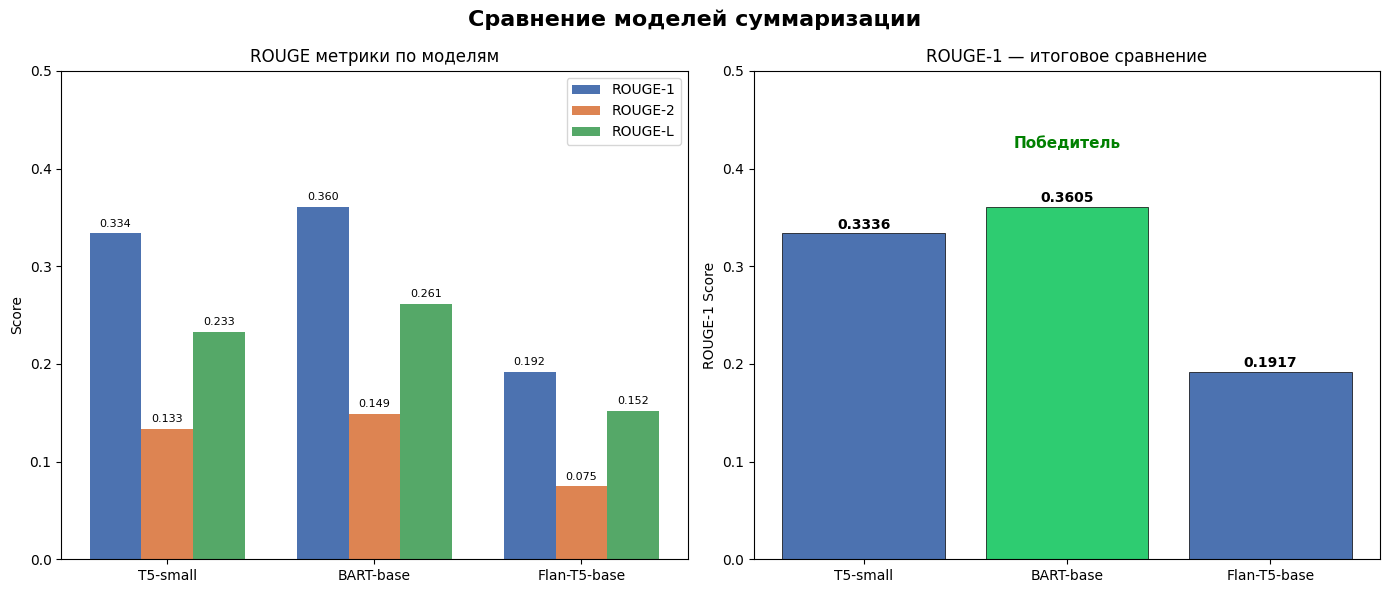


График сохранён: model_comparison.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Итоговая таблица

results = [results_t5, results_bart, results_flan]
df_results = pd.DataFrame(results).set_index('model')

print("=== Итоговая таблица метрик ROUGE ===")
print(df_results.to_string())

# График сравнения

models = ['T5-small', 'BART-base', 'Flan-T5-base']
rouge1 = [results_t5['ROUGE-1'], results_bart['ROUGE-1'], results_flan['ROUGE-1']]
rouge2 = [results_t5['ROUGE-2'], results_bart['ROUGE-2'], results_flan['ROUGE-2']]
rougeL = [results_t5['ROUGE-L'], results_bart['ROUGE-L'], results_flan['ROUGE-L']]

x = np.arange(len(models))
width = 0.25

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Сравнение моделей суммаризации', fontsize=16, fontweight='bold')

# График 1 — сгруппированные столбцы
bars1 = axes[0].bar(x - width, rouge1, width, label='ROUGE-1', color='#4C72B0')
bars2 = axes[0].bar(x, rouge2, width, label='ROUGE-2', color='#DD8452')
bars3 = axes[0].bar(x + width, rougeL, width, label='ROUGE-L', color='#55A868')

axes[0].set_title('ROUGE метрики по моделям')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models)
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 0.5)
axes[0].legend()

# Подписи значений
for bar in [bars1, bars2, bars3]:
    for rect in bar:
        height = rect.get_height()
        axes[0].text(
            rect.get_x() + rect.get_width() / 2.,
            height + 0.005,
            f'{height:.3f}',
            ha='center', va='bottom', fontsize=8
        )

# График 2 — ROUGE-1 с выделением победителя
colors = ['#4C72B0', '#2ecc71', '#4C72B0']
axes[1].bar(models, rouge1, color=colors, edgecolor='black', linewidth=0.5)
axes[1].set_title('ROUGE-1 — итоговое сравнение')
axes[1].set_ylabel('ROUGE-1 Score')
axes[1].set_ylim(0, 0.5)

for i, v in enumerate(rouge1):
    axes[1].text(i, v + 0.005, f'{v:.4f}', ha='center', fontweight='bold')

axes[1].annotate('Победитель', xy=(1, rouge1[1]),
                 xytext=(1, rouge1[1] + 0.06),
                 ha='center', fontsize=11, color='green', fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nГрафик сохранён: model_comparison.png")

# Вывод по моделям

## Выводы

В ходе работы были обучены и сравнены три модели суммаризации текста на датасете из Лабы 3 (MeetingBank + CNN/DailyMail).

### Результаты

| Модель | ROUGE-1 | ROUGE-2 | ROUGE-L |
|---|---|---|---|
| T5-small | 0.3336 | 0.1330 | 0.2331 |
| Flan-T5-base | 0.1917 | 0.0746 | 0.1521 |
| **BART-base** ✅ | **0.3605** | **0.1492** | **0.2611** |

### Почему победил BART-base

Как я думаю, это из-за того что BART изначально создавался для генерации текста и суммаризации,поэтому даже на небольшом датасете показал лучший результат .

Flan-T5-base оказался слишком большим для нашего объёма данных - 250 млн параметров не успели нормально обучиться за 3 эпохи. (возможно он бы и выиграл, но обучение займет слишком много времени)

### Итог

Для задачи автоматического конспектирования лекций выбираем BART-base как наилучшую модель.

# Использование на реальном видео

In [ ]:
# Установка зависимостей
!pip install yt-dlp openai-whisper -q
!apt-get install -y ffmpeg -q

# Скачиваем аудио с YouTube
import yt_dlp

URL = "https://youtu.be/1A_CAkYt3GY"

ydl_opts = {
    'format': 'bestaudio/best',
    'outtmpl': 'lecture.%(ext)s',
    'postprocessors': [{
        'key': 'FFmpegExtractAudio',
        'preferredcodec': 'mp3',
        'preferredquality': '192',
    }],
    'quiet': True
}

with yt_dlp.YoutubeDL(ydl_opts) as ydl:
    info = ydl.extract_info(URL, download=True)
    title = info['title']
    duration = info['duration']

print(f"Скачано: {title}")
print(f"Длительность: {duration // 60} мин {duration % 60} сек")

# Транскрибируем через Whisper
import whisper

print("\nЗагружаем Whisper tiny...")
whisper_model = whisper.load_model("tiny")

print("Транскрибируем аудио (подождите)...")
result = whisper_model.transcribe("lecture.mp3")
transcript = result['text']

print(f"Транскрипция завершена")
print(f"Длина транскрипта: {len(transcript)} символов")
print(f"\nНачало транскрипта:\n{transcript[:500]}")


# Генерируем конспект через BART-base

print("\nГенерируем конспект...")

def wrap_text(text, width=80):
    words = text.split()
    lines = []
    current_line = []
    current_len = 0
    for word in words:
        if current_len + len(word) + 1 > width:
            lines.append(' '.join(current_line))
            current_line = [word]
            current_len = len(word)
        else:
            current_line.append(word)
            current_len += len(word) + 1
    if current_line:
        lines.append(' '.join(current_line))
    return '\n'.join(lines)

transcript_chunk = transcript[:1000]
summary = generate_summary(model_bart, tokenizer_bart, transcript_chunk, prefix="")

print("=== КОНСПЕКТ ЛЕКЦИИ ===")
print(f"Название: {title}\n")
print("--- ТРАНСКРИПТ (первые 1000 символов) ---")
print(wrap_text(transcript_chunk))
print("\n--- КОНСПЕКТ ---")
print(wrap_text(summary))

Reading package lists...
Building dependency tree...
Reading state information...
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 42 not upgraded.


Скачано: What is Philosophy?: Crash Course Philosophy #1
Длительность: 10 мин 35 сек

Загружаем Whisper tiny...
Транскрибируем аудио (подождите)...
Транскрипция завершена
Длина транскрипта: 12173 символов

Начало транскрипта:
 Crash Course Philosophy is brought to you by Squarespace. Squarespace, share your passion with the world. I'm Hank Green, and you and I are about to embark on a journey, a journey of inquiry into the whole world, your world. In an effort to figure out what gives it meaning what makes it beautiful, where its evils come from, and ultimately what is the very nature of reality itself. The long way, we're going to question every aspect of your own personal life. Why do you do what you do? Why do you

Генерируем конспект...
=== КОНСПЕКТ ЛЕКЦИИ ===
Название: What is Philosophy?: Crash Course Philosophy #1

--- ТРАНСКРИПТ (первые 1000 символов) ---
Crash Course Philosophy is brought to you by Squarespace. Squarespace, share
your passion with the world. I'm Hank Green, an